In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="0wyZ9c4UVXiCL3KKbovj")
project = rf.workspace("preeshas-workspace").project("railway-crack-detection-rlamm-rel8w")
version = project.version(5)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Railway-Crack-Detection-5 in yolov8:: 100%|██████████| 5449/5449 [00:01<00:00, 5246.61it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
with open('/content/Railway-Crack-Detection-5/data.yaml', 'w') as f:
    f.write("""path: /content/Railway-Crack-Detection-5

train: train/images
val: valid/images

nc: 1
names: ['railway_gap']
""")

In [ ]:
import os

print("Train images:", os.path.exists('/content/Railway-Crack-Detection-5/train/images'))
print("Valid images:", os.path.exists('/content/Railway-Crack-Detection-5/valid/images'))

Train images: True
Valid images: True


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8l.pt')  # 🔥 bigger model = better accuracy

model.train(
    data='/content/Railway-Crack-Detection-5/data.yaml',
    epochs=90,
    imgsz=640,      # keep safe
    batch=16,        # stable
    patience=50,

    optimizer='AdamW',
    lr0=0.0005,

    augment=True,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0
)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Railway-Crack-Detection-5/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=90, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f48d855b3e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 


image 1/1 /content/Railway-Crack-Detection-5/test/images/Image-163_jpg.rf.a5412ff0791d9864707884264a9af8f0.jpg: 640x480 2 railway_gaps, 52.7ms
Speed: 1.7ms preprocess, 52.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/Railway-Crack-Detection-5/test/images/Image-164_jpg.rf.0e6727065704b11ac961df6545422ec0.jpg: 480x640 1 railway_gap, 53.1ms
Speed: 1.4ms preprocess, 53.1ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/Railway-Crack-Detection-5/test/images/387463605_385533223827035_6813258457814046414_n_jpg.rf.040685f66f1182a1b2264639a501b283.jpg: 288x640 1 railway_gap, 48.9ms
Speed: 1.6ms preprocess, 48.9ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 640)

image 1/1 /content/Railway-Crack-Detection-5/test/images/Image-131_jpg.rf.ca5435cffc4902c716ef257337a4cac0.jpg: 640x480 2 railway_gaps, 42.6ms
Speed: 1.3ms preprocess, 42.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


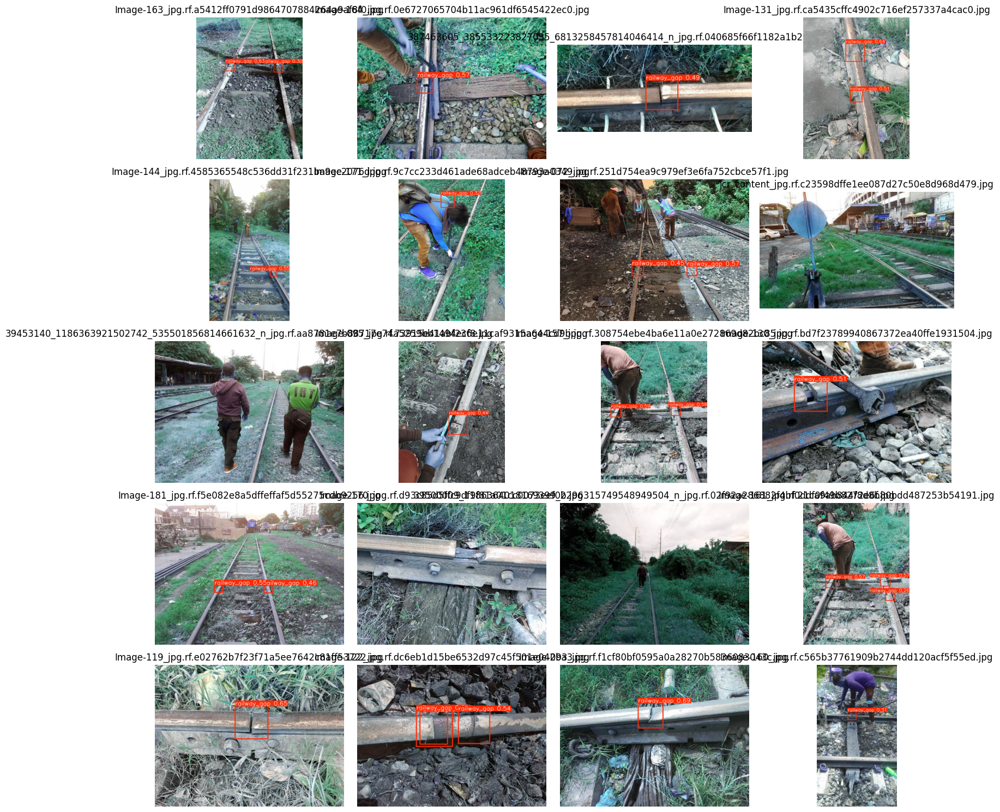

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os
import random

# Load model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Folder with test images
folder = '/content/Railway-Crack-Detection-5/test/images'

# Get image list
images = os.listdir(folder)

# Pick 20 random images
images = random.sample(images, 20)

plt.figure(figsize=(15, 15))

for i, img_name in enumerate(images):
    path = os.path.join(folder, img_name)

    # High recall detection
    results = model.predict(path, conf=0.2)

    # Plot result
    img = results[0].plot()

    plt.subplot(5, 4, i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

results = model.predict(
    source='/content/Railway-Crack-Detection-5/test/images',
    conf=0.4,     # balanced recall + confidence
    iou=0.5,
    save=True      # saves output images
)


image 1/104 /content/Railway-Crack-Detection-5/test/images/01560jfSanta_Mesa_PNR_Station_Pandacan_Railway_tracks_Manilafvf_10_jpg.rf.45b52bcec56be8d9be18217162eb0641.jpg: 480x640 (no detections), 53.0ms
image 2/104 /content/Railway-Crack-Detection-5/test/images/13112778_948141415254768_1259631035748969821_o_jpg.rf.c94032a53058dcc85196428a434badee.jpg: 640x480 (no detections), 48.5ms
image 3/104 /content/Railway-Crack-Detection-5/test/images/370130530_852604809689003_4697102894634927590_n_jpg.rf.e06ef31177838b5b42171d0deecc66c1.jpg: 288x640 1 railway_gap, 37.9ms
image 4/104 /content/Railway-Crack-Detection-5/test/images/387463605_385533223827035_6813258457814046414_n_jpg.rf.040685f66f1182a1b2264639a501b283.jpg: 288x640 1 railway_gap, 20.3ms
image 5/104 /content/Railway-Crack-Detection-5/test/images/39442305_1186363924836075_715879677108944896_n_jpg.rf.de1ad26db867d9a35577043b82014e22.jpg: 480x640 (no detections), 30.0ms
image 6/104 /content/Railway-Crack-Detection-5/test/images/3945314

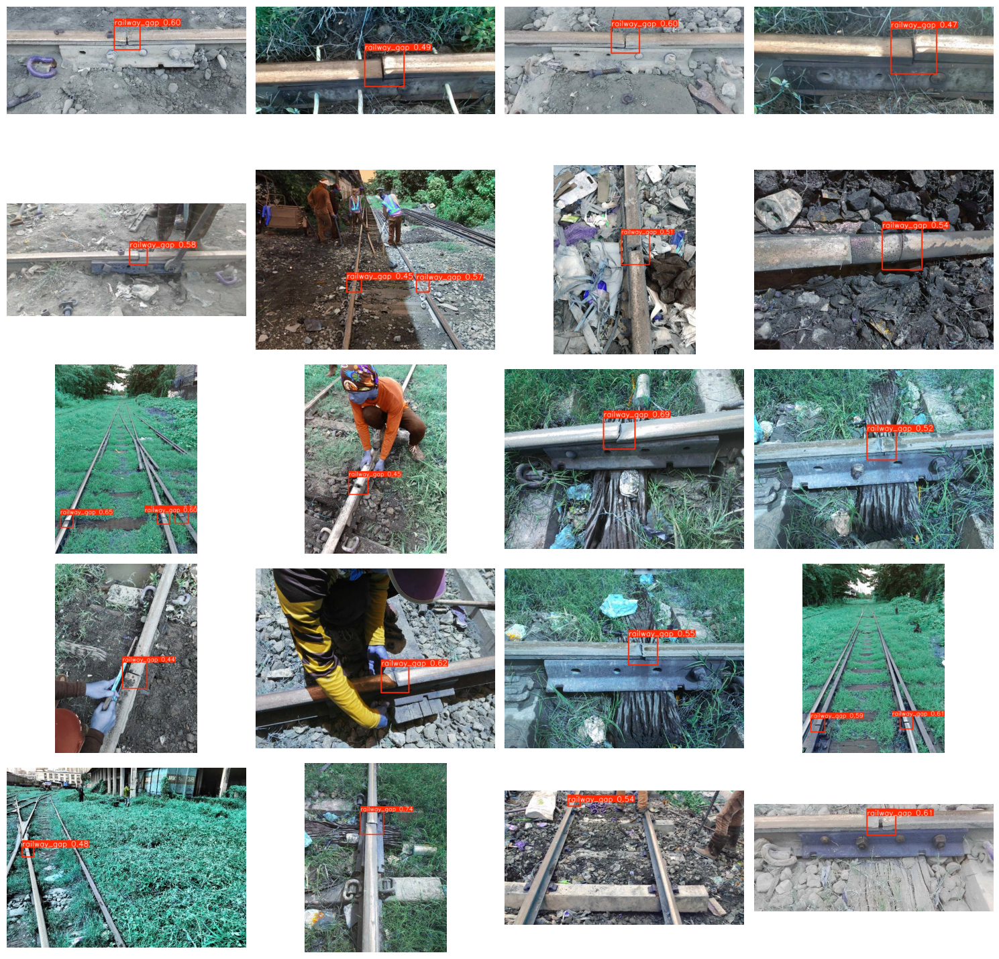

In [ ]:
import matplotlib.pyplot as plt

count = 0
plt.figure(figsize=(15,15))

for r in results:
    if r.boxes is not None and len(r.boxes) > 0:
        img = r.plot()

        plt.subplot(5,4,count+1)
        plt.imshow(img)
        plt.axis('off')

        count += 1
        if count == 20:
            break

plt.tight_layout()
plt.show()


image 1/104 /content/Railway-Crack-Detection-5/test/images/01560jfSanta_Mesa_PNR_Station_Pandacan_Railway_tracks_Manilafvf_10_jpg.rf.45b52bcec56be8d9be18217162eb0641.jpg: 480x640 (no detections), 52.4ms
image 2/104 /content/Railway-Crack-Detection-5/test/images/13112778_948141415254768_1259631035748969821_o_jpg.rf.c94032a53058dcc85196428a434badee.jpg: 640x480 (no detections), 33.2ms
image 3/104 /content/Railway-Crack-Detection-5/test/images/370130530_852604809689003_4697102894634927590_n_jpg.rf.e06ef31177838b5b42171d0deecc66c1.jpg: 288x640 2 railway_gaps, 24.7ms
image 4/104 /content/Railway-Crack-Detection-5/test/images/387463605_385533223827035_6813258457814046414_n_jpg.rf.040685f66f1182a1b2264639a501b283.jpg: 288x640 1 railway_gap, 23.8ms
image 5/104 /content/Railway-Crack-Detection-5/test/images/39442305_1186363924836075_715879677108944896_n_jpg.rf.de1ad26db867d9a35577043b82014e22.jpg: 480x640 (no detections), 34.6ms
image 6/104 /content/Railway-Crack-Detection-5/test/images/394531

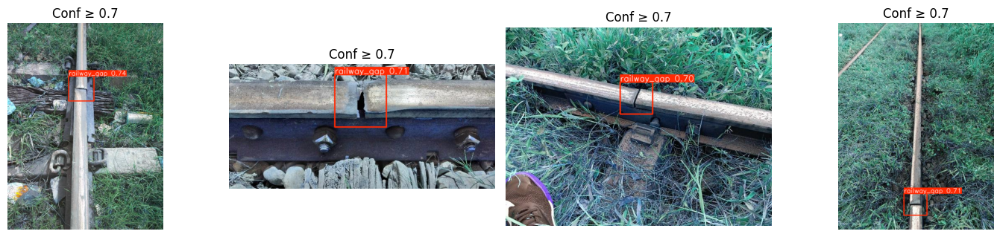

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO('/content/runs/detect/train/weights/best.pt')

# Run detection
results = model.predict(
    source='/content/Railway-Crack-Detection-5/test/images',
    conf=0.1  # keep low initially to capture all
)

plt.figure(figsize=(15,15))
count = 0

for r in results:
    if r.boxes is not None and len(r.boxes) > 0:
        # Filter boxes with confidence >= 0.7
        keep = r.boxes.conf > 0.7

        if keep.sum() > 0:
            r.boxes = r.boxes[keep]
            img = r.plot()

            plt.subplot(5,4,count+1)
            plt.imshow(img)
            plt.title("Conf ≥ 0.7")
            plt.axis('off')

            count += 1

            if count == 20:   # show 20 strong images
                break

plt.tight_layout()
plt.show()

In [ ]:
for r in results:
    if r.boxes is not None:
        for box, conf in zip(r.boxes.xyxy, r.boxes.conf):
            if conf > 0.7:
                print("Confidence:", float(conf))

Confidence: 0.7368391156196594
Confidence: 0.7079259157180786
Confidence: 0.7038838863372803
Confidence: 0.7108485102653503


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO('/content/runs/detect/train/weights/best.pt')

# Run detection (keep low conf first to capture all)
results = model.predict(
    source='/content/Railway-Crack-Detection-5/test/images',
    conf=0.1
)

plt.figure(figsize=(15,15))
count = 0

for r in results:
    if r.boxes is not None and len(r.boxes) > 0:

        # Keep only strong detections ≥ 0.8
        keep = r.boxes.conf > 0.8

        if keep.sum() > 0:
            r.boxes = r.boxes[keep]
            img = r.plot()

            plt.subplot(5,4,count+1)
            plt.imshow(img)
            plt.title("Conf ≥ 0.8")
            plt.axis('off')

            count += 1

            if count == 20:   # show 20 strong detections
                break

plt.tight_layout()
plt.show()


image 1/104 /content/Railway-Crack-Detection-5/test/images/01560jfSanta_Mesa_PNR_Station_Pandacan_Railway_tracks_Manilafvf_10_jpg.rf.45b52bcec56be8d9be18217162eb0641.jpg: 480x640 (no detections), 53.3ms
image 2/104 /content/Railway-Crack-Detection-5/test/images/13112778_948141415254768_1259631035748969821_o_jpg.rf.c94032a53058dcc85196428a434badee.jpg: 640x480 (no detections), 48.3ms
image 3/104 /content/Railway-Crack-Detection-5/test/images/370130530_852604809689003_4697102894634927590_n_jpg.rf.e06ef31177838b5b42171d0deecc66c1.jpg: 288x640 2 railway_gaps, 37.9ms
image 4/104 /content/Railway-Crack-Detection-5/test/images/387463605_385533223827035_6813258457814046414_n_jpg.rf.040685f66f1182a1b2264639a501b283.jpg: 288x640 1 railway_gap, 27.4ms
image 5/104 /content/Railway-Crack-Detection-5/test/images/39442305_1186363924836075_715879677108944896_n_jpg.rf.de1ad26db867d9a35577043b82014e22.jpg: 480x640 (no detections), 30.3ms
image 6/104 /content/Railway-Crack-Detection-5/test/images/394531

<Figure size 1500x1500 with 0 Axes>

In [ ]:
from google.colab import files
files.download('/content/model.zip')

FileNotFoundError: Cannot find file: /content/model.zip

In [ ]:
import zipfile

zip_path = '/content/model.zip'
model_path = '/content/runs/detect/train/weights/best.pt'

with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(model_path, arcname='best.pt')

print("ZIP created!")

ZIP created!


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'yolo26n.pt', 'model.zip', 'yolov8l.pt', 'runs', 'Railway-Crack-Detection-5', 'sample_data']


In [ ]:
from google.colab import files
files.download('/content/model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

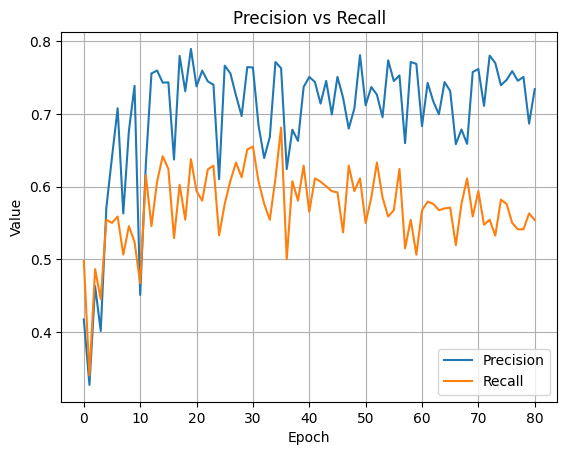

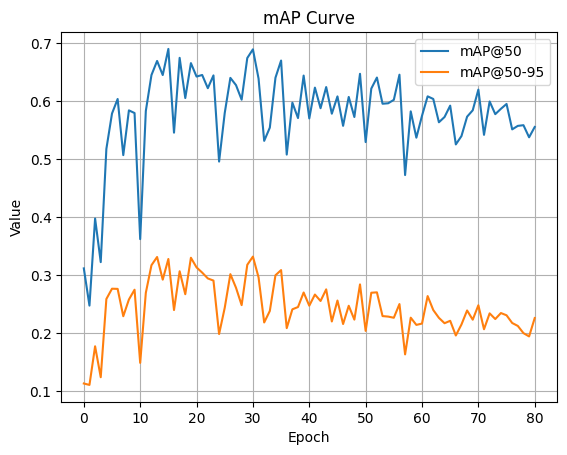

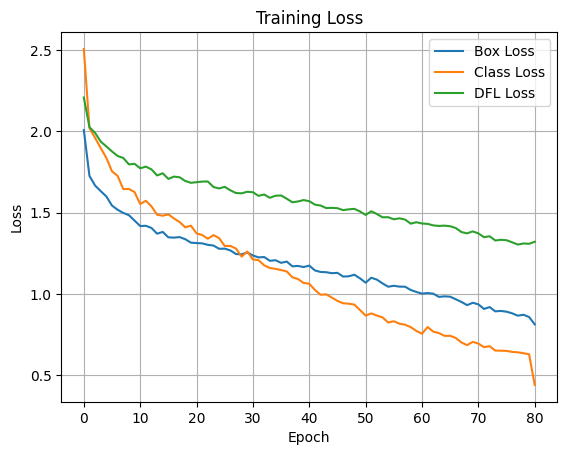

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv('/content/runs/detect/train/results.csv')

# Plot Precision & Recall
plt.figure()
plt.plot(df['metrics/precision(B)'], label='Precision')
plt.plot(df['metrics/recall(B)'], label='Recall')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Precision vs Recall')
plt.legend()
plt.grid()
plt.show()

# Plot mAP
plt.figure()
plt.plot(df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(df['metrics/mAP50-95(B)'], label='mAP@50-95')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('mAP Curve')
plt.legend()
plt.grid()
plt.show()

# Plot Losses
plt.figure()
plt.plot(df['train/box_loss'], label='Box Loss')
plt.plot(df['train/cls_loss'], label='Class Loss')
plt.plot(df['train/dfl_loss'], label='DFL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid()
plt.show()

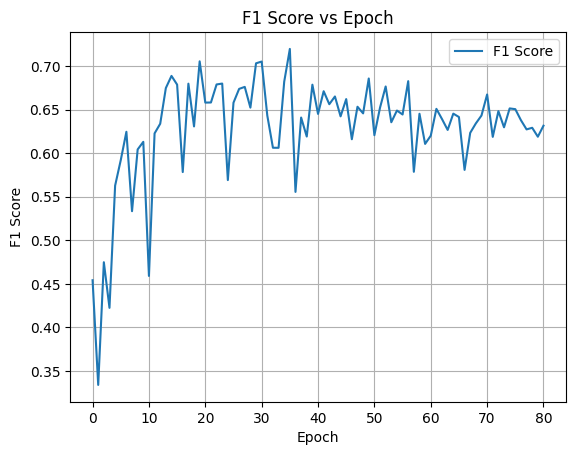

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv('/content/runs/detect/train/results.csv')

# Calculate F1 score
precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']

f1 = 2 * (precision * recall) / (precision + recall)

# Plot F1
plt.figure()
plt.plot(f1, label='F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Epoch')
plt.legend()
plt.grid()
plt.show()

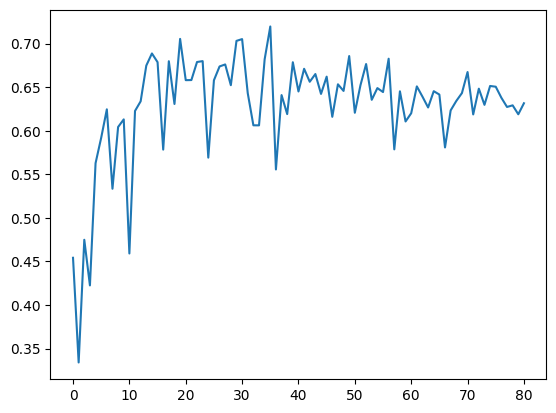

In [ ]:
plt.figure()
plt.plot(f1)
plt.savefig('/content/f1_score.png')

In [ ]:
import os
print(os.listdir('/content/runs/detect/train'))

['val_batch1_pred.jpg', 'BoxPR_curve.png', 'train_batch1.jpg', 'confusion_matrix_normalized.png', 'BoxF1_curve.png', 'BoxP_curve.png', 'results.png', 'val_batch2_pred.jpg', 'train_batch0.jpg', 'BoxR_curve.png', 'args.yaml', 'train_batch12081.jpg', 'val_batch0_labels.jpg', 'val_batch2_labels.jpg', 'labels.jpg', 'results.csv', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'weights', 'train_batch12080.jpg', 'train_batch12082.jpg', 'confusion_matrix.png', 'train_batch2.jpg']


(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

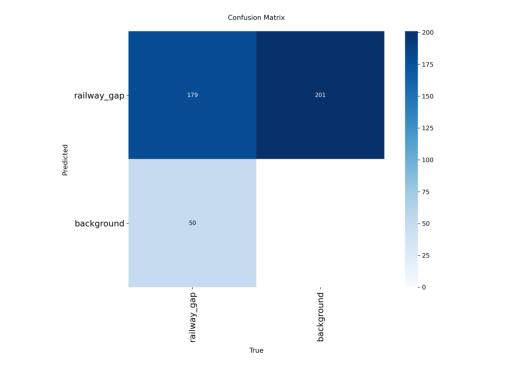

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/runs/detect/train/confusion_matrix.png')

plt.imshow(img)
plt.axis('off')

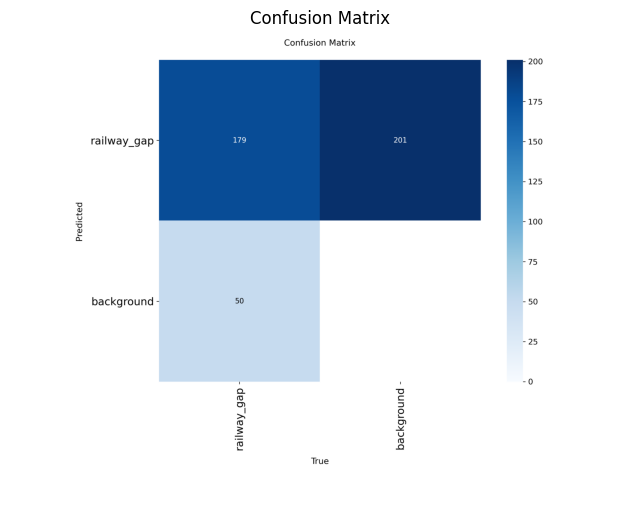

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/runs/detect/train/confusion_matrix.png')

plt.figure(figsize=(8,8))   # 🔥 bigger image
plt.imshow(img)
plt.title("Confusion Matrix")
plt.axis('off')
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

results = model.predict(
    source='/content/Railway-Crack-Detection-5/test/images',
    conf=0.45,     # balanced recall + confidence
    iou=0.6,
    save=True      # saves output images
)


image 1/104 /content/Railway-Crack-Detection-5/test/images/01560jfSanta_Mesa_PNR_Station_Pandacan_Railway_tracks_Manilafvf_10_jpg.rf.45b52bcec56be8d9be18217162eb0641.jpg: 480x640 (no detections), 53.0ms
image 2/104 /content/Railway-Crack-Detection-5/test/images/13112778_948141415254768_1259631035748969821_o_jpg.rf.c94032a53058dcc85196428a434badee.jpg: 640x480 (no detections), 34.1ms
image 3/104 /content/Railway-Crack-Detection-5/test/images/370130530_852604809689003_4697102894634927590_n_jpg.rf.e06ef31177838b5b42171d0deecc66c1.jpg: 288x640 1 railway_gap, 25.5ms
image 4/104 /content/Railway-Crack-Detection-5/test/images/387463605_385533223827035_6813258457814046414_n_jpg.rf.040685f66f1182a1b2264639a501b283.jpg: 288x640 1 railway_gap, 24.5ms
image 5/104 /content/Railway-Crack-Detection-5/test/images/39442305_1186363924836075_715879677108944896_n_jpg.rf.de1ad26db867d9a35577043b82014e22.jpg: 480x640 (no detections), 35.8ms
image 6/104 /content/Railway-Crack-Detection-5/test/images/3945314

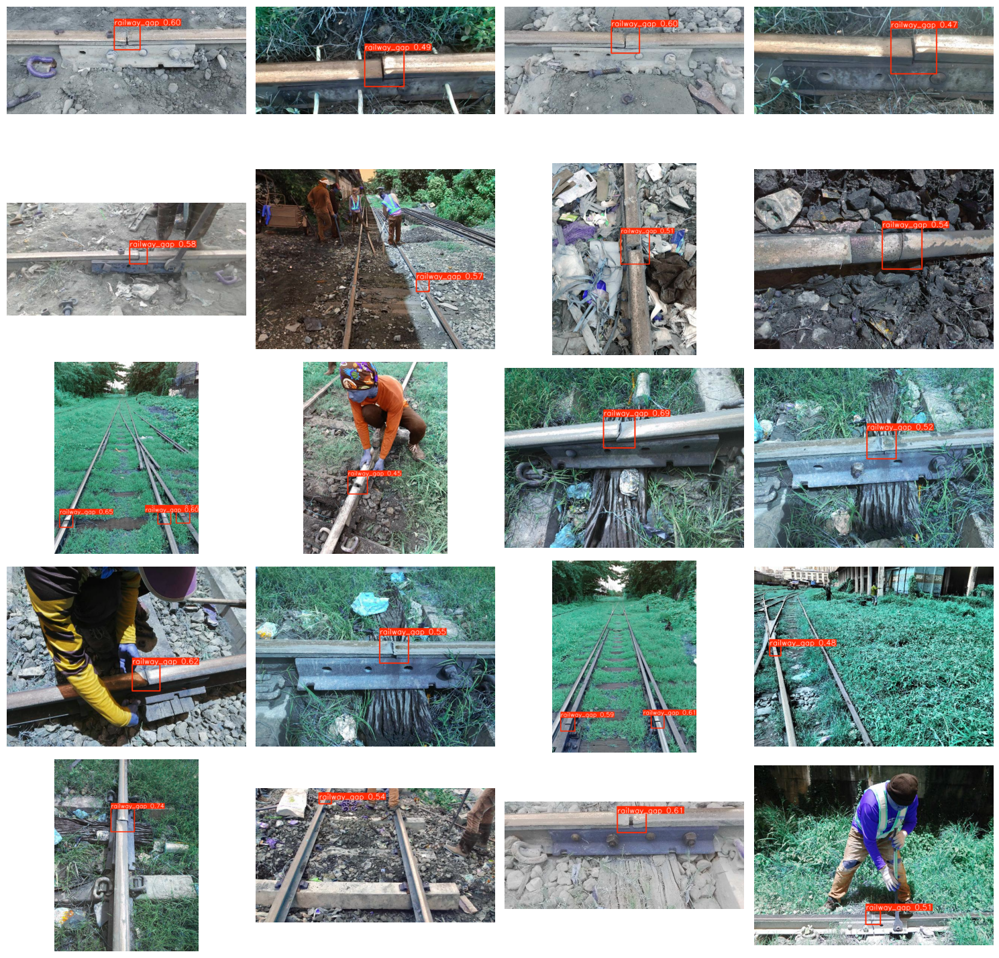

In [ ]:
import matplotlib.pyplot as plt

count = 0
plt.figure(figsize=(15,15))

for r in results:
    if r.boxes is not None and len(r.boxes) > 0:
        img = r.plot()

        plt.subplot(5,4,count+1)
        plt.imshow(img)
        plt.axis('off')

        count += 1
        if count == 20:
            break

plt.tight_layout()
plt.show()

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/best.pt')  # change path if needed

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/best.pt'

In [ ]:
from google.colab import files
uploaded = files.upload()